# 4 — Model Evaluation

Notebook di **report finale**. Carica il modello addestrato dallo script `train_model.py` e produce una valutazione completa con grafici e analisi degli errori.

---

## 4.1 — Caricamento Modello e Dati

In [3]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# --- Caricamento Modello ---
model = joblib.load('../models/final_model.joblib')
print(f'✅ Modello caricato: {type(model).__name__}')

# --- Caricamento Test Set ---
test_df = pd.read_csv('../data/processed/KICKSTARTER_TEST.csv')
X_test = test_df.drop('target', axis=1)
y_test = test_df['target']

# --- Predizioni ---
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(f'📊 Test Set: {X_test.shape}')
print(f'📊 Predizioni generate: {len(y_pred)}')

✅ Modello caricato: LGBMClassifier
📊 Test Set: (37623, 367)
📊 Predizioni generate: 37623


---
## 4.2 — Classification Report

In [4]:
print('--- 📋 CLASSIFICATION REPORT ---\n')
print(classification_report(y_test, y_pred, target_names=['Failed (0)', 'Successful (1)']))

# Anche in formato DataFrame per visualizzazione migliore
report_dict = classification_report(y_test, y_pred, target_names=['Failed (0)', 'Successful (1)'], output_dict=True)
report_df = pd.DataFrame(report_dict).T
report_df.style.format('{:.4f}').background_gradient(cmap='YlGn', subset=['precision', 'recall', 'f1-score'])

--- 📋 CLASSIFICATION REPORT ---

                precision    recall  f1-score   support

    Failed (0)       0.77      0.70      0.73     14234
Successful (1)       0.83      0.87      0.85     23389

      accuracy                           0.81     37623
     macro avg       0.80      0.79      0.79     37623
  weighted avg       0.81      0.81      0.81     37623



,precision,recall,f1-score,support
Failed (0),0.7684,0.7037,0.7346,14234.0000
Successful (1),0.8285,0.8709,0.8492,23389.0000
accuracy,0.8076,0.8076,0.8076,0.8076
macro avg,0.7984,0.7873,0.7919,37623.0000
weighted avg,0.8057,0.8076,0.8058,37623.0000


---
## 4.3 — Confusion Matrix

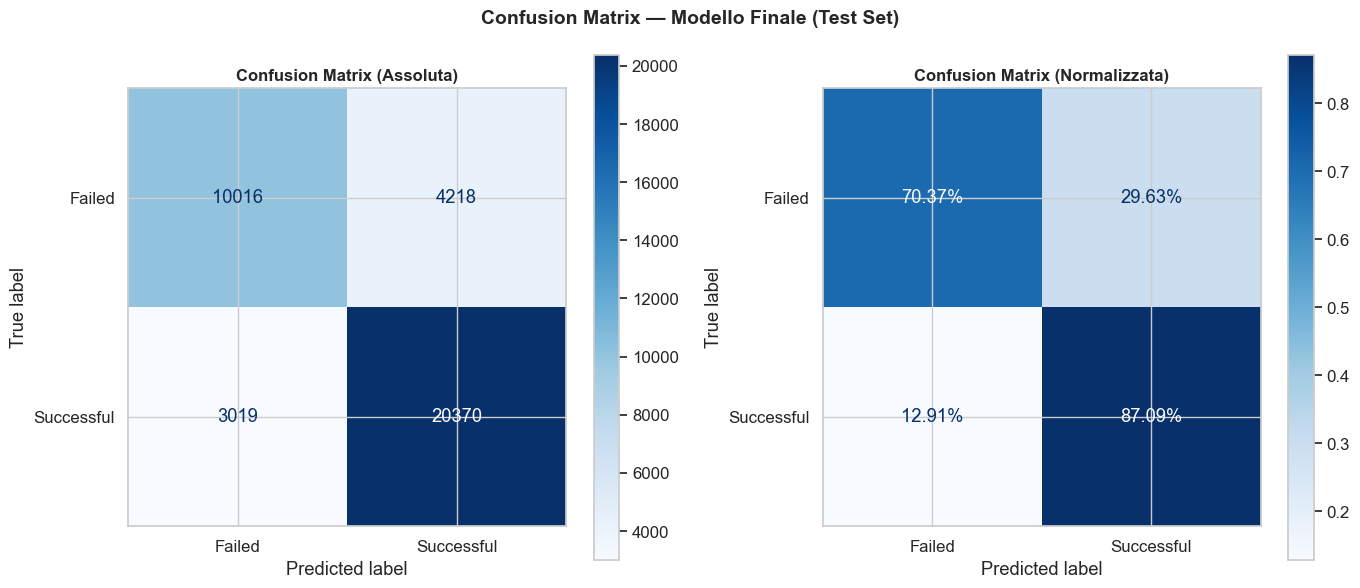

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion Matrix — Valori Assoluti
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Failed', 'Successful'])
disp.plot(cmap='Blues', ax=axes[0], values_format='d')
axes[0].set_title('Confusion Matrix (Assoluta)', fontsize=12, fontweight='bold')

# Confusion Matrix — Normalizzata
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=['Failed', 'Successful'])
disp_norm.plot(cmap='Blues', ax=axes[1], values_format='.2%')
axes[1].set_title('Confusion Matrix (Normalizzata)', fontsize=12, fontweight='bold')

fig.suptitle('Confusion Matrix — Modello Finale (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4.4 — ROC Curve

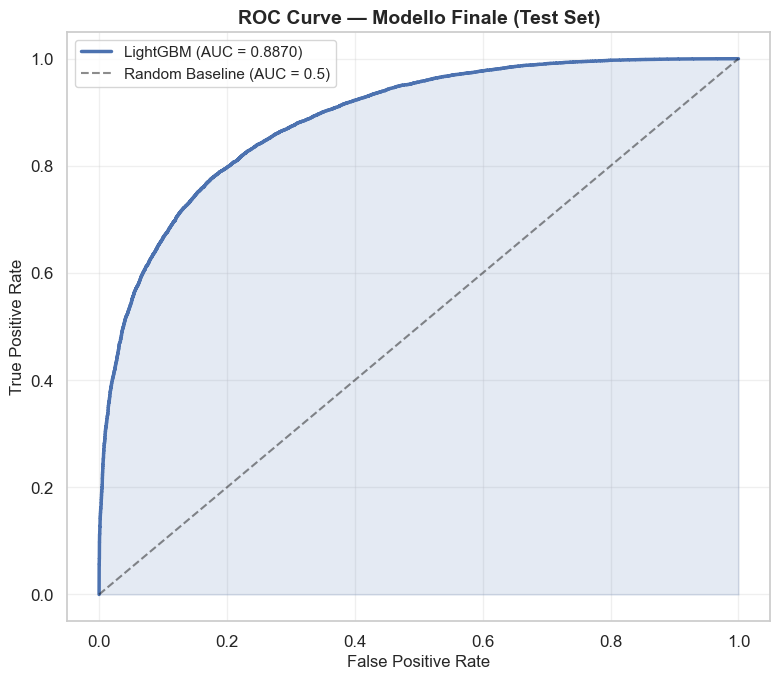

📊 AUC-ROC: 0.8870


In [6]:
fig, ax = plt.subplots(figsize=(8, 7))

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_val = roc_auc_score(y_test, y_proba)

ax.plot(fpr, tpr, color='#4C72B0', linewidth=2.5, label=f'LightGBM (AUC = {auc_val:.4f})')
ax.fill_between(fpr, tpr, alpha=0.15, color='#4C72B0')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Baseline (AUC = 0.5)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Modello Finale (Test Set)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'📊 AUC-ROC: {auc_val:.4f}')

---
## 4.5 — Feature Importance (Top 20)

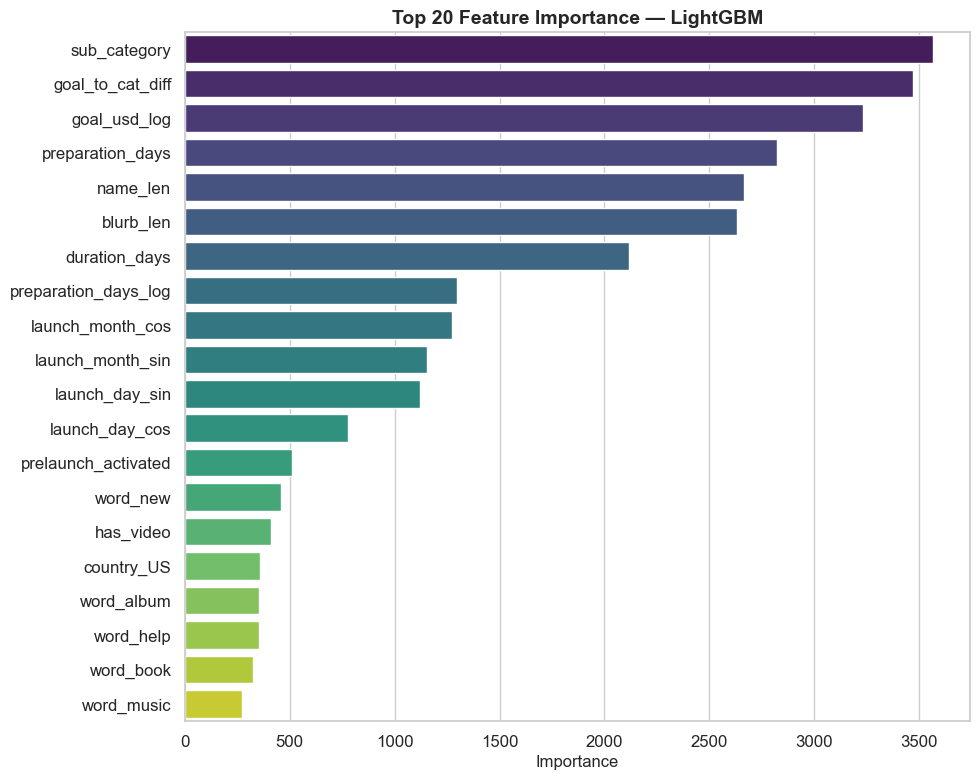

,feature,importance
0,sub_category,3565
1,goal_to_cat_diff,3468
2,goal_usd_log,3230
3,preparation_days,2821
4,name_len,2666
5,blurb_len,2632
6,duration_days,2117
7,preparation_days_log,1296
8,launch_month_cos,1272
9,launch_month_sin,1155


In [7]:
importances = model.feature_importances_
feature_names = X_test.columns

fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi_df = fi_df.sort_values(by='importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
colors = sns.color_palette('viridis', n_colors=20)
sns.barplot(x='importance', y='feature', data=fi_df, hue='feature', palette='viridis', legend=False, ax=ax)
ax.set_title('Top 20 Feature Importance — LightGBM', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance', fontsize=12)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

# Tabella
fi_df.reset_index(drop=True)

---
## 4.6 — Analisi Errori

Analizziamo le caratteristiche dei campioni **mal classificati** (False Positives e False Negatives) per capire dove il modello fatica.

In [8]:
# Costruzione DataFrame con predizioni
results_df = X_test.copy()
results_df['y_true'] = y_test.values
results_df['y_pred'] = y_pred
results_df['y_proba'] = y_proba
results_df['correct'] = (results_df['y_true'] == results_df['y_pred'])

# Classificazione errori
results_df['error_type'] = 'Correct'
results_df.loc[(results_df['y_true'] == 0) & (results_df['y_pred'] == 1), 'error_type'] = 'False Positive'
results_df.loc[(results_df['y_true'] == 1) & (results_df['y_pred'] == 0), 'error_type'] = 'False Negative'

error_counts = results_df['error_type'].value_counts()
print('📊 Distribuzione Errori:')
print(error_counts)
print(f'\n📊 Tasso di errore complessivo: {(~results_df["correct"]).mean():.2%}')

📊 Distribuzione Errori:
error_type
Correct           30386
False Positive     4218
False Negative     3019
Name: count, dtype: int64

📊 Tasso di errore complessivo: 19.24%


In [9]:
# Selezioniamo le feature numeriche principali per il confronto
key_features = ['goal_usd_log', 'duration_days', 'name_len', 'blurb_len']
key_features = [f for f in key_features if f in results_df.columns]

if key_features:
    # Statistiche per tipo di errore
    error_stats = results_df.groupby('error_type')[key_features].agg(['mean', 'median', 'std'])
    print('\n--- 📊 STATISTICHE PER TIPO DI ERRORE ---\n')
    display(error_stats)
else:
    print('⚠️ Feature chiave non trovate nel dataset.')


--- 📊 STATISTICHE PER TIPO DI ERRORE ---



goal_usd_log                     duration_days         \
                       mean    median       std          mean median   
error_type                                                             
Correct            8.283669  8.400823  1.731795     32.749292   30.0   
False Negative     8.573942  8.527342  1.557999     35.985757   30.0   
False Positive     8.074015  8.214737  1.551458     31.484827   30.0   

                            name_len                     blurb_len         \
                      std       mean median        std        mean median   
error_type                                                                  
Correct         12.592454  35.282564   35.0  15.629910  104.829329  117.0   
False Negative  13.524324  33.653196   32.0  15.333534  104.072541  117.0   
False Positive  11.199821  36.804173   37.0  15.282559  103.920816  116.0   

                           
                      std  
error_type                 
Correct         31.231975  
False Negative  32.158854  
False Positive  31.635243

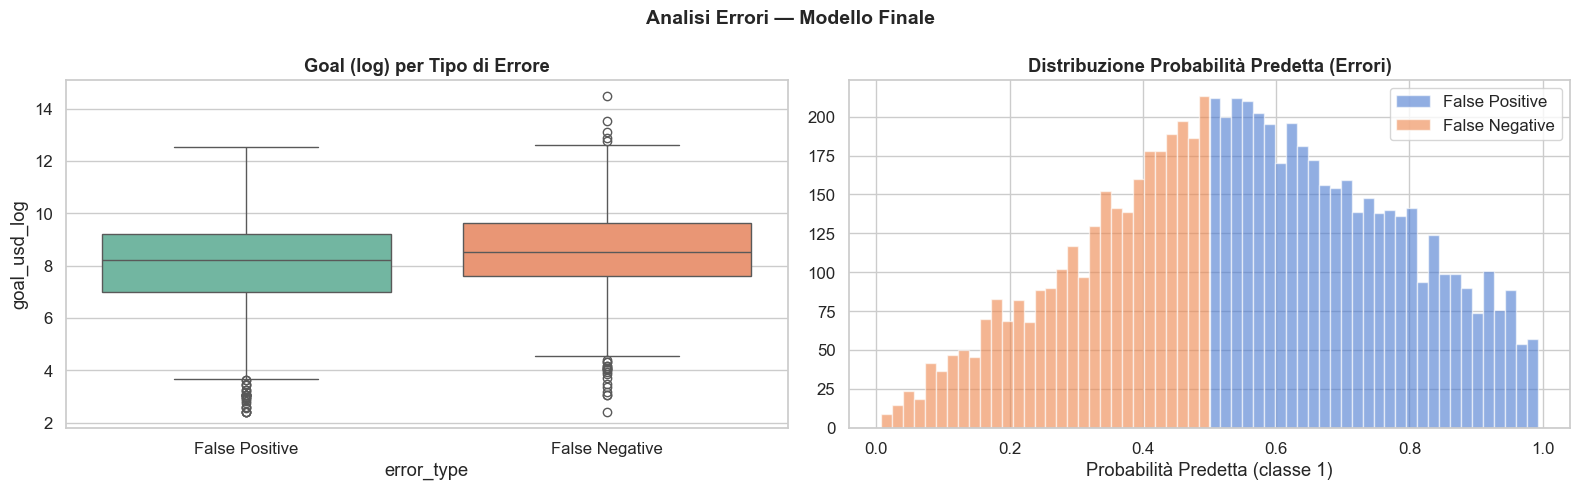

In [10]:
# Visualizzazione: distribuzione goal_usd_log per tipo di errore
if 'goal_usd_log' in results_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Box plot
    errors_only = results_df[results_df['error_type'] != 'Correct']
    if len(errors_only) > 0:
        sns.boxplot(x='error_type', y='goal_usd_log', data=errors_only, ax=axes[0], palette='Set2')
        axes[0].set_title('Goal (log) per Tipo di Errore', fontweight='bold')
    
    # Distribuzione probabilità predetta per errori
    if len(errors_only) > 0:
        for etype in ['False Positive', 'False Negative']:
            subset = errors_only[errors_only['error_type'] == etype]['y_proba']
            if len(subset) > 0:
                axes[1].hist(subset, bins=30, alpha=0.6, label=etype)
        axes[1].set_title('Distribuzione Probabilità Predetta (Errori)', fontweight='bold')
        axes[1].set_xlabel('Probabilità Predetta (classe 1)')
        axes[1].legend()
    
    fig.suptitle('Analisi Errori — Modello Finale', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Campioni più "sicuramente sbagliati" (alta confidenza errata)

In [11]:
# False Positives con probabilità più alta (il modello era molto sicuro, ma ha sbagliato)
fp_confident = results_df[results_df['error_type'] == 'False Positive'].nlargest(10, 'y_proba')
fn_confident = results_df[results_df['error_type'] == 'False Negative'].nsmallest(10, 'y_proba')

print('--- 🔴 Top 10 False Positive più confidenti ---')
display(fp_confident[['y_proba'] + key_features].reset_index(drop=True) if key_features else fp_confident[['y_proba']].reset_index(drop=True))

print('\n--- 🔵 Top 10 False Negative più confidenti ---')
display(fn_confident[['y_proba'] + key_features].reset_index(drop=True) if key_features else fn_confident[['y_proba']].reset_index(drop=True))

--- 🔴 Top 10 False Positive più confidenti ---


,y_proba,goal_usd_log,duration_days,name_len,blurb_len
0,0.992254,9.210440,30,48,64
1,0.991918,6.216606,23,13,128
2,0.991891,5.600850,30,58,123
3,0.991492,4.668602,10,15,135
4,0.991023,6.498633,20,37,110
5,0.990833,5.413251,18,43,97
6,0.990498,7.039741,29,12,135
7,0.988340,8.779711,33,53,111
8,0.987757,6.398595,20,52,29
9,0.987676,8.006701,30,30,106



--- 🔵 Top 10 False Negative più confidenti ---


,y_proba,goal_usd_log,duration_days,name_len,blurb_len
0,0.007877,11.539479,40,12,39
1,0.008629,11.041337,30,51,90
2,0.010860,9.210440,30,17,91
3,0.013515,9.998843,60,33,68
4,0.016335,10.019046,60,11,130
5,0.017576,9.903538,29,21,121
6,0.018768,9.215583,30,13,123
7,0.021423,8.517393,60,17,135
8,0.023286,7.884524,30,39,131
9,0.026190,10.915107,59,20,127


---
## Conclusioni

Il modello LightGBM finale dimostra buone capacità predittive sul Test Set. L'analisi degli errori evidenzia:

- I **False Positive** (progetti predetti come successi ma falliti) tendono ad avere caratteristiche simili ai progetti di successo
- I **False Negative** (progetti predetti come fallimenti ma di successo) rappresentano casi atipici
- La distribuzione delle probabilità sugli errori mostra che la maggior parte degli errori avviene nella zona di incertezza (probabilità vicina a 0.5)

---
*Report di valutazione finale — KickProphet*